In [ ]:
import cv2

def blur_face(img):
  (h, w) = img.shape[:2]
  dW = int(w / 3.0)
  dH = int(h / 3.0)
  if dW % 2 == 0:
      dW -= 1
  if dH % 2 == 0:
      dH -= 1
  return cv2.GaussianBlur(img, (dW, dH), 0)



Text(0.5, 1.0, 'Какой-то неизвестный мужчина')

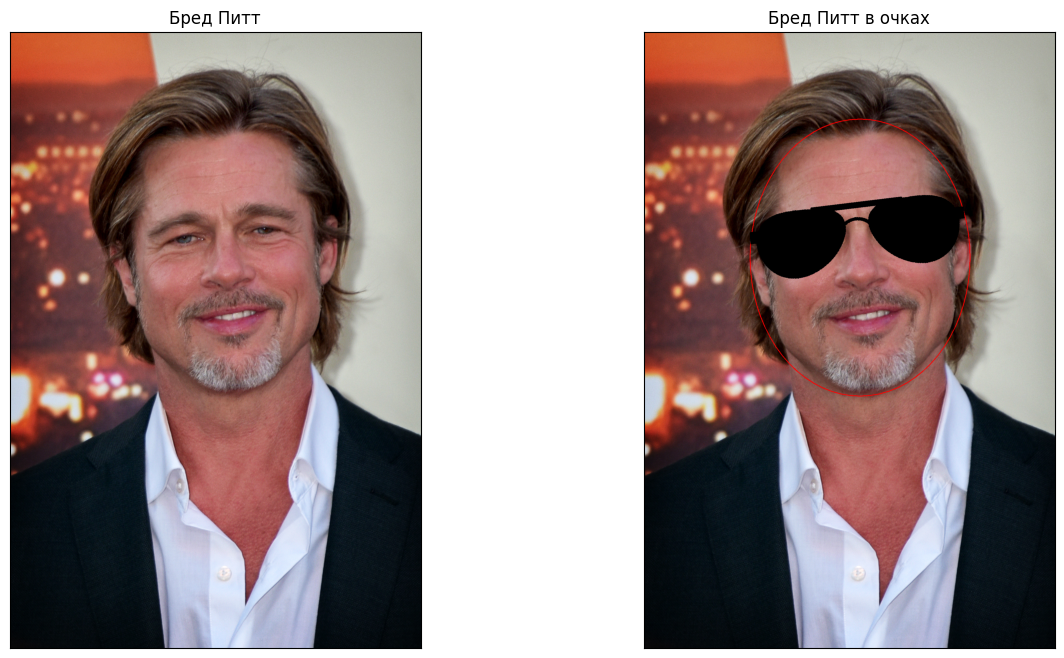

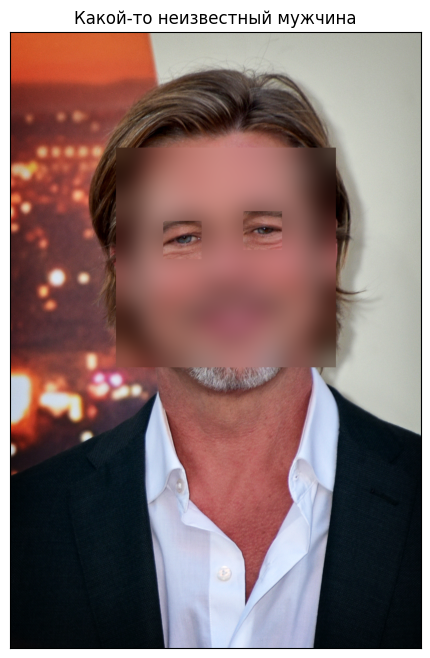

In [ ]:
import gdown
import numpy as np
from matplotlib import pyplot

gdown.download('https://storage.yandexcloud.net/opencv-photo/Brad_Pitt_2019_by_Glenn_Francis.jpg', None, quiet=True)
gdown.download('https://storage.yandexcloud.net/opencv-photo/sunglasses3.png', None, quiet=True)

img_face = cv2.imread('./Brad_Pitt_2019_by_Glenn_Francis.jpg')
img_sunglasses = cv2.imread('./sunglasses3.png')
img2_face = img_face.copy()
img_blured = img_face.copy()

classifier_face = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
classifier_eye = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

bboxes = classifier_face.detectMultiScale(img_face, scaleFactor=2, minNeighbors=3, minSize=(50, 50))

for box in bboxes:
    x, y, width, height = box
    x2, y2 = x + width, y + height
    x_center = int(x + width/2)
    y_center = int(y + height/2)

    cv2.ellipse(img2_face,
        (x_center, y_center),
        (int(width/2), int(height/2) + 100),
        angle=0,
        startAngle=0,
        endAngle=360,
        color=(0, 0, 255), thickness=2)

    face = img2_face[y:y2, x:x2]

    face_blured = blur_face(face)

    eyes = classifier_eye.detectMultiScale(img2_face[y:y+int(3*height/4), x:x2], scaleFactor=1.2, minNeighbors=3, minSize=(100, 100))

    for (x_eye,y_eye,w_eye,h_eye) in eyes:
        face_blured[y_eye:y_eye+h_eye ,x_eye:x_eye+w_eye] = face[y_eye:y_eye+h_eye ,x_eye:x_eye+w_eye]

    img_blured[y:y2, x:x2] = face_blured

    if len(eyes) == 2:
        (mx0, my0, mw0, mh0) = eyes[0]
        (mx, my, mw, mh) = eyes[1]

        # Находим угол для поворота изображения очков
        vect1 = np.abs(mx0 - mx)
        vect2 = np.abs(my0 - my)
        vect3 = np.sqrt(vect1 ** 2 + vect2 ** 2)
        cos_a = vect1 / vect3
        angle_a = np.rad2deg(np.arccos(cos_a))

        my -=240
        mh *=5
        eye = face[my:my+mh, 0:width]

        rot_matrix_gl = cv2.getRotationMatrix2D((int(np.min([mx0, mx])), int(my+mh/2)), angle_a, 1)
        img_sunglasses = cv2.resize(img_sunglasses, (width, mh), interpolation=cv2.INTER_AREA)
        sunglasses_copy = img_sunglasses.copy()

        # Поворачиваем изображение с очками и убираем лишний черный фон, который появляется после поворота изображения
        sunglasses_copy_grey = cv2.cvtColor(sunglasses_copy, cv2.COLOR_BGR2GRAY)
        _, white_m = cv2.threshold(sunglasses_copy_grey, 0, 255, cv2.THRESH_BINARY_INV)
        sunglasses_copy_rotate = cv2.warpAffine(white_m, rot_matrix_gl, (white_m.shape[1], white_m.shape[0]))
        sunglasses_copy_rotate = cv2.threshold(sunglasses_copy_rotate, 0, 255, cv2.THRESH_BINARY_INV)[1]
        sunglasses_copy_rotate = cv2.cvtColor(sunglasses_copy_rotate, cv2.COLOR_BGR2RGB)

        # Добавляем очки на фото
        gray_mask_sunglasses = cv2.cvtColor(sunglasses_copy_rotate, cv2.COLOR_BGR2GRAY)
        ret, mask = cv2.threshold(gray_mask_sunglasses, 0, 255, cv2.THRESH_BINARY_INV)

        mask_inv = cv2.bitwise_not(mask)

        masked_face = cv2.bitwise_and(eye, eye, mask=mask_inv)

        masked_eye = cv2.bitwise_and(sunglasses_copy_rotate, sunglasses_copy_rotate, mask=mask)

        face[my:my+mh, 0:width] = cv2.add(masked_face, masked_eye)


fig, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(15, 8))
ax1.imshow(cv2.cvtColor(img_face, cv2.COLOR_BGR2RGB))
ax1.xaxis.set_ticks([])
ax1.yaxis.set_ticks([])
ax1.set_title('Бред Питт')

ax2.imshow(cv2.cvtColor(img2_face, cv2.COLOR_BGR2RGB))
ax2.xaxis.set_ticks([])
ax2.yaxis.set_ticks([])
ax2.set_title('Бред Питт в очках')

fig, ax = pyplot.subplots(1, 1, figsize=(15, 8))
ax.imshow(cv2.cvtColor(img_blured, cv2.COLOR_BGR2RGB))
ax.xaxis.set_ticks([])
ax.yaxis.set_ticks([])
ax.set_title('Какой-то неизвестный мужчина')